In [1]:
import pandas as pd
import numpy as np
from pathlib import Path


records = []
yymmdd = '240813'
cell = 'cell0001'
spine_types = ['BLA', 'CA3']
main_matrix_ids = [] # ['M1', 'M2'] # , 'mm6', 'mm7']
for i in range(1,21):
    id = str(i)
    m_id = 'M' + id
    main_matrix_ids.append(m_id)

date_str = '30_08_2026'

for main_matrix_id in main_matrix_ids:      # nuovo loop esterno

    for spine_type in spine_types:

        # --- experiment ---
        data_path_exp = Path('D:/') / f"{yymmdd}_{cell}_{spine_type}_{main_matrix_id}_{date_str}_experiment" / "output_soma_v"
        for file in sorted(data_path_exp.glob("*.npy")):

            records.append({
                "main_matrix_id": main_matrix_id,
                "date_str": date_str,
                "spine_type": spine_type,
                "condition": "experiment",
                "filename": file.name,
                "data": np.load(file),
                "path": file,
            })

        # --- random ---
        data_path_rnd = Path('D:/') / f"{yymmdd}_{cell}_{spine_type}_{main_matrix_id}_{date_str}" / "output_soma_v"
        for file in sorted(data_path_rnd.glob("*.npy")):
            if file.name.startswith("._"):
                continue
            records.append({
                "main_matrix_id": main_matrix_id,
                "date_str": date_str,
                "spine_type": spine_type,
                "condition": "random",
                "filename": file.name,
                "data": np.load(file, allow_pickle=True),
                "path": file,
            })

df = pd.DataFrame(records)


In [2]:
df.to_pickle("D:/dataset_M1_M20_30_08_2026.pkl") # li salva in un file .pkl
aus_data = df.loc[
            (df["spine_type"] == 'CA3') &
            (df["main_matrix_id"] == 'M3') &
            (df["condition"] == 'experiment')
        ]

aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm


array([-66.        , -65.99607431, -65.99170014, ..., -66.27902727,
       -66.27364161, -66.26864205], shape=(32001,))

In [3]:
main_matrix_ids

['M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'M10',
 'M11',
 'M12',
 'M13',
 'M14',
 'M15',
 'M16',
 'M17',
 'M18',
 'M19',
 'M20']

In [4]:
spine_types = ['BLA', 'CA3']
#main_matrix_ids = ['mm3', 'mm4', 'mm5', 'mm6', 'mm7']
# main_matrix_ids = ['M1', 'M2']
cond = ['experiment']
# spine_types
# main_matrix_ids
distances_exp = {}
ref_Vs = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp[(SpineType, mm, 'experiment')] = aus_distances


In [5]:
spine_types = ['BLA', 'CA3']
# main_matrix_ids = ['mm3'] # , 'mm4', 'mm5', 'mm6', 'mm7']

cond = ['random']
# spine_types
# main_matrix_ids
distances_sim = {}
ref_Vs = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim[(SpineType, mm, 'random')] = aus_distances


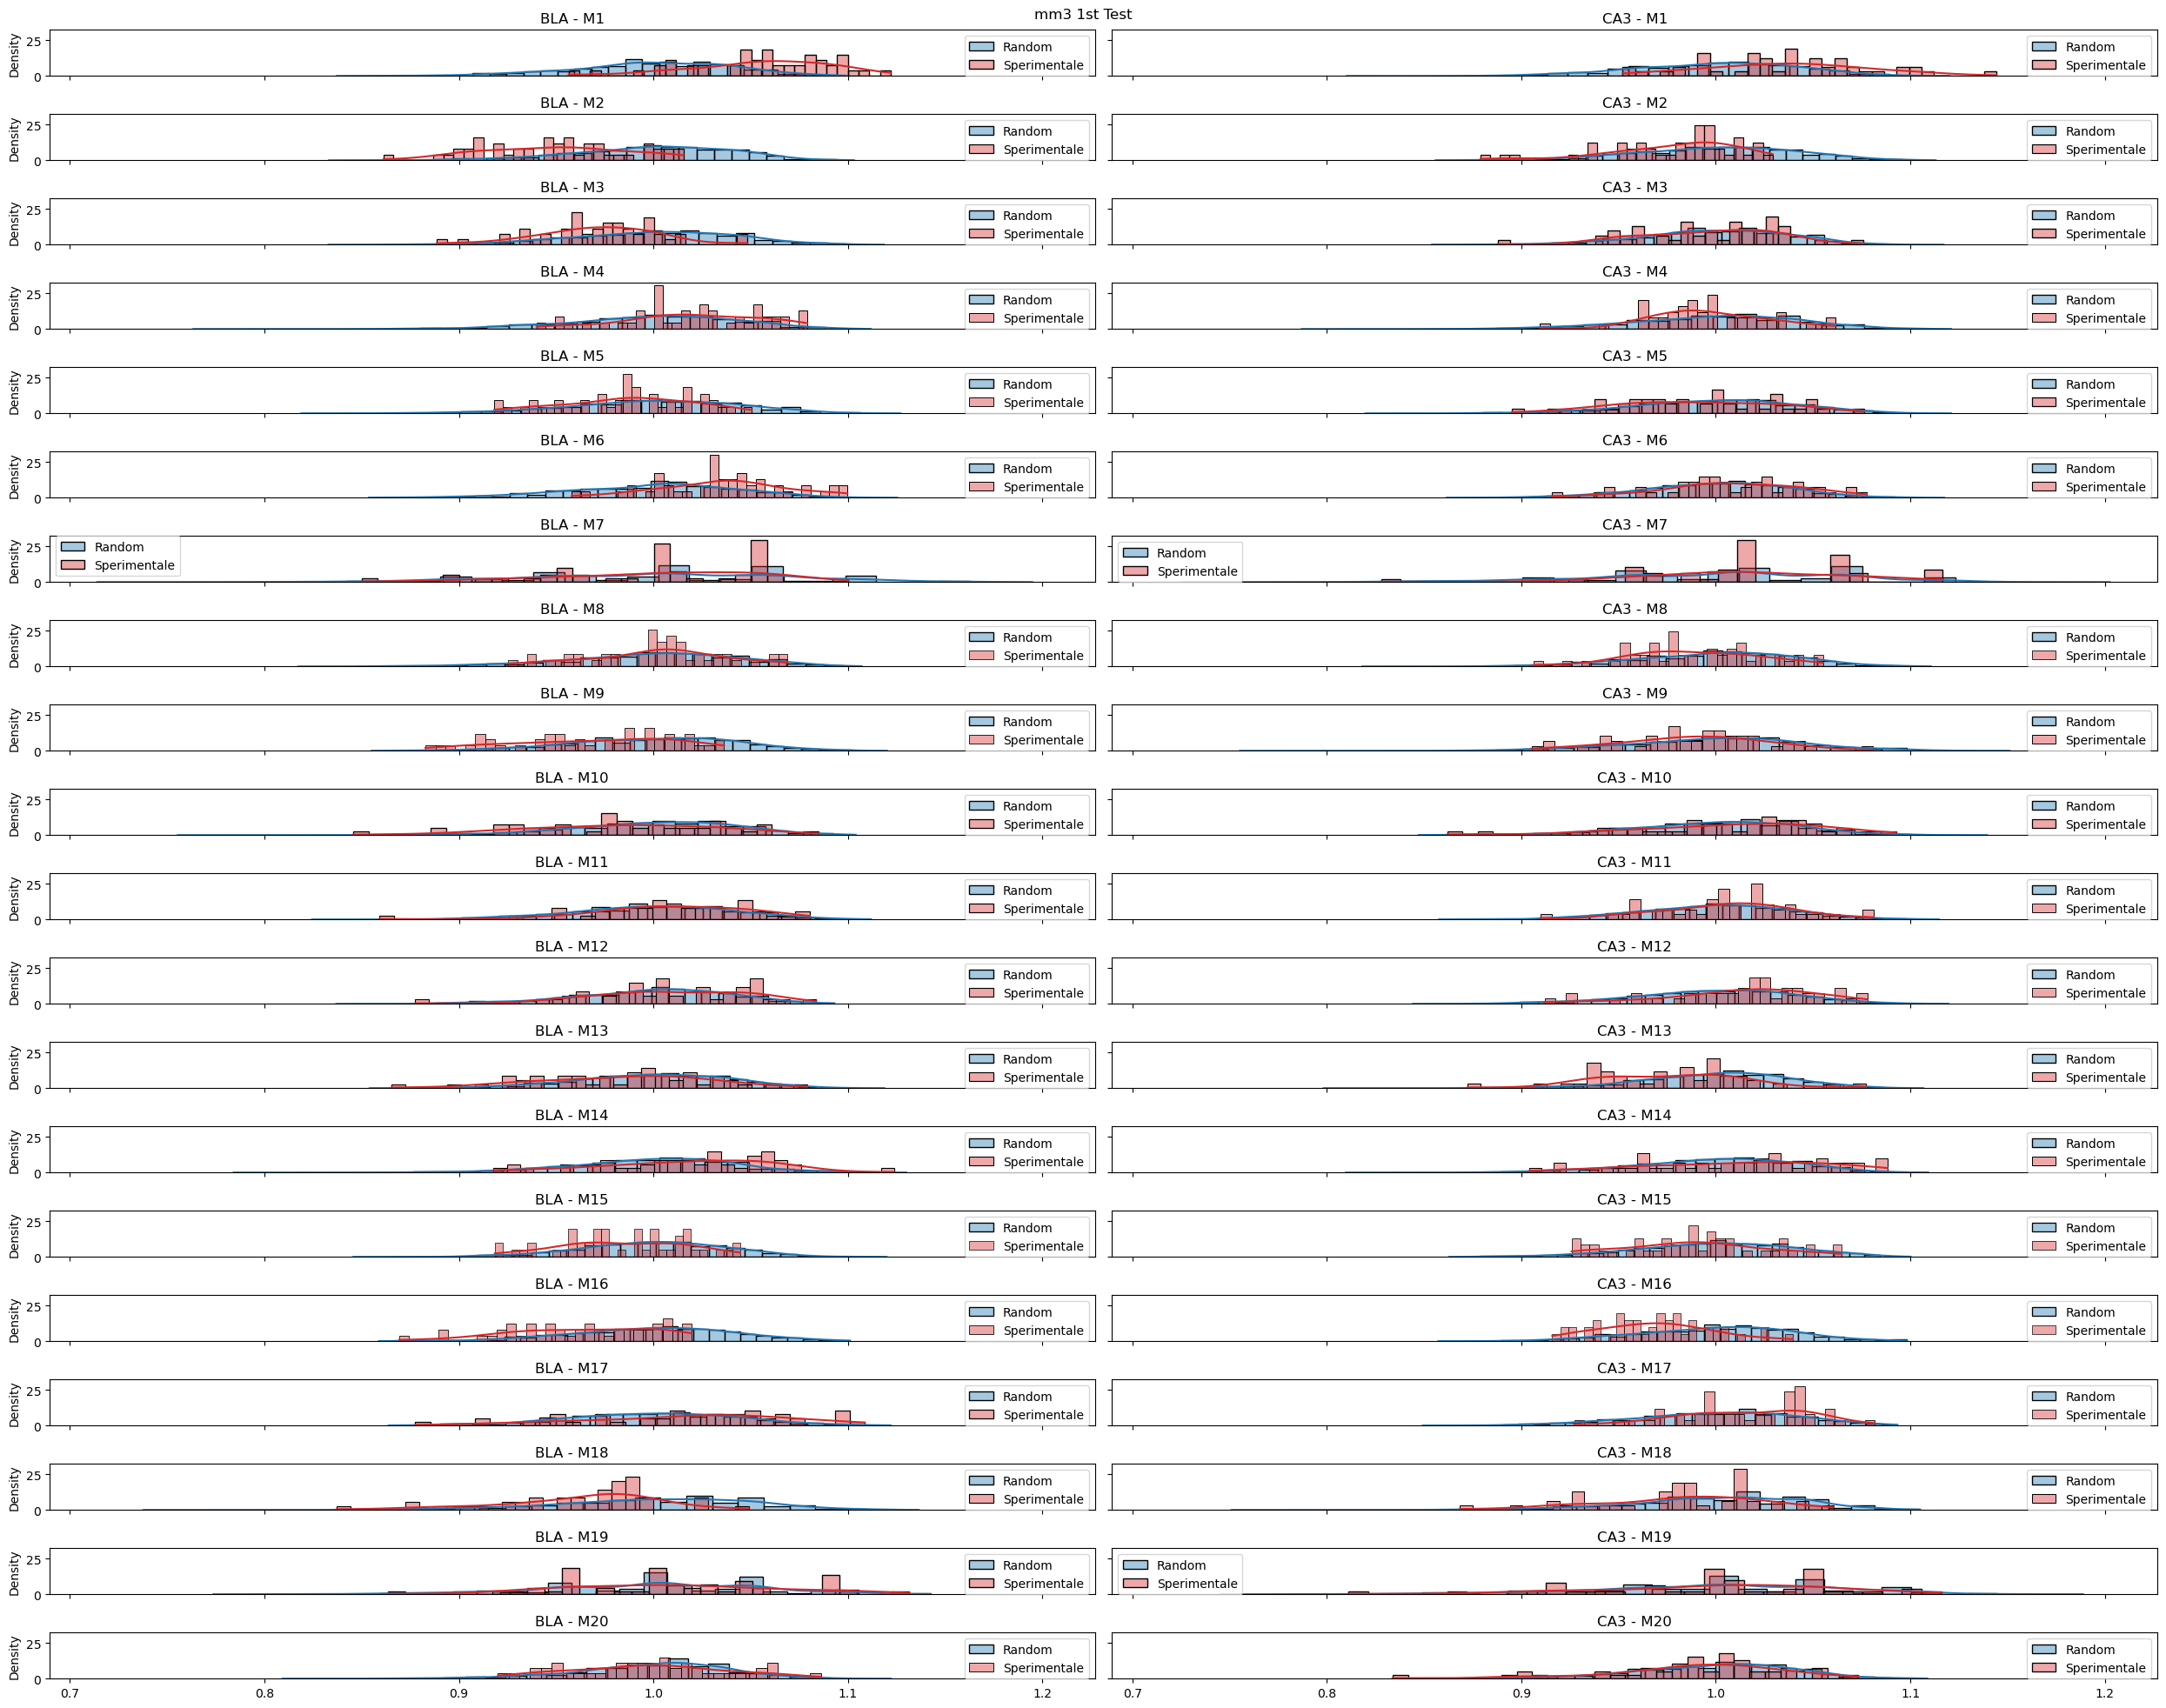

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
# mms = ['mm3'] # , 'mm4', 'mm5','mm6','mm7']
regions = ['BLA', 'CA3']
mms = main_matrix_ids
fig, axes = plt.subplots(
    len(mms), 2,
    figsize=(25, 20),
    sharex=True,
    sharey=True
)
fig.suptitle('mm3 1st Test')
for i, mm in enumerate(mms):
    for j, region in enumerate(regions):

        ax = axes[i,j]

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )

        # dati sperimentali
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )

            # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        d_exp = exp_data / mu
        sns.histplot(
            d_sim,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Random',
            color='tab:blue',
            ax=ax
        )
        sns.histplot(
            d_exp,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Sperimentale',
            color='tab:red',
            ax=ax
        )
        ax.legend()
        ax.set_title(f'{region} - {mm}')

#plt.xlim([0.75, 1.15])
#plt.ylim([0, 40])

plt.tight_layout()
plt.show()

In [7]:
'''all_d = {}
for j, region in enumerate(regions):
    all_d[(region)] = []
    for i, mm in enumerate(mms):
        d_exp = distances_exp[region,mm,'experiment']
        d_sim = distances_sim[region,mm,'random']

        all_d[(region)].append((d_sim, d_exp))

import numpy as np
'''
all_d = {}
for region in regions:
    d_sim_all = []
    d_exp_all = []

    for mm in mms:
        d_exp = distances_exp[region, mm, 'experiment']
        d_sim = distances_sim[region, mm, 'random']

        mu = np.mean(d_sim)

        d_sim_all.append(d_sim/mu)
        d_exp_all.append(d_exp/mu)

    all_d[region] = {
    'sim': np.array(d_sim_all),
    'exp': np.array(d_exp_all)
}


#all_d_exp_arr = np.array(all_d_exp)
#alld_sim_arr = np.array(all_d_sim)

In [8]:
all_d_sim_BLA = all_d['BLA']['sim']

all_d_exp_BLA = all_d['BLA']['exp']

all_d_exp_CA3 = all_d['CA3']['exp']
all_d_sim_CA3 = all_d['CA3']['sim']

In [9]:
all_d_exp_BLA = np.asarray(all_d_exp_BLA).flatten()
all_d_sim_BLA = np.asarray(all_d_sim_BLA).flatten()

all_d_exp_CA3 = np.asarray(all_d_exp_CA3).flatten()
all_d_sim_CA3 = np.asarray(all_d_sim_CA3).flatten()


In [83]:
'''
mu_BLA = np.mean(all_d_sim_BLA)
mu_CA3 = np.mean(all_d_sim_CA3)

# normalizzazione
d_sim_BLA = all_d_sim_BLA / mu_BLA
d_exp_BLA = all_d_exp_BLA / mu_BLA

d_sim_CA3 = all_d_sim_CA3 / mu_CA3
d_exp_CA3 = all_d_exp_CA3 / mu_CA3

'''

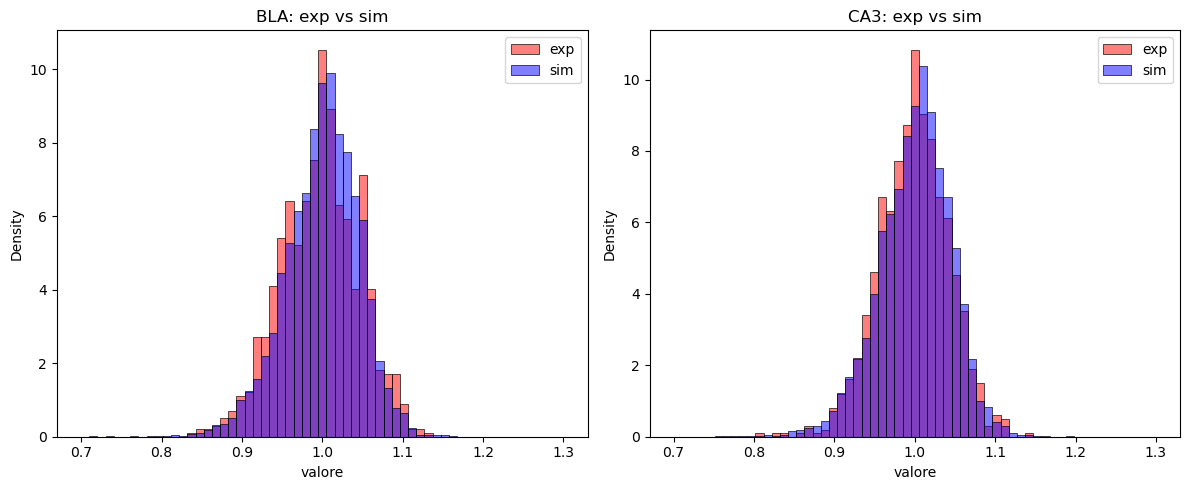

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins_n= np.linspace(0.7,1.3,60)

# ----- istogramma BLA: exp vs sim sovrapposti -----
sns.histplot(all_d_exp_BLA, stat='density', label='exp', color='red', alpha=0.5, ax=axes[0],bins=bins_n)
sns.histplot(all_d_sim_BLA, stat='density', label='sim', color='blue', alpha=0.5, ax=axes[0],bins=bins_n)
axes[0].set_title('BLA: exp vs sim')
axes[0].set_xlabel('valore')
axes[0].legend()

# ----- istogramma CA3: exp vs sim sovrapposti -----
sns.histplot(all_d_exp_CA3, stat='density', label='exp', color='red', alpha=0.5, ax=axes[1],bins=bins_n)
sns.histplot(all_d_sim_CA3, stat='density', label='sim', color='blue', alpha=0.5, ax=axes[1],bins=bins_n)
axes[1].set_title('CA3: exp vs sim')
axes[1].set_xlabel('valore')
axes[1].legend()

np
plt.tight_layout()
plt.show()